In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Motif binding score (see analysis code for calculation)
erg_binding_csv = "binding_score_at_motifs/ERG/ERG__orig-human__loc-prom__motif-GABPA.H12CORE.0.PSM.A__type-family__fl25__nuc-7-25-50__trim150.csv"

# Extracted footprint file (see analysis code for calculation)
erg_fp_csv = "../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/representative_hoco_motif/raw_signals/ERG_raw_windows.csv"

## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Optional, Sequence
from matplotlib.colors import ListedColormap

## Helper Functions

In [4]:
# Get the position columns available in a dataframe
def _pos_cols_in(df: pd.DataFrame, rng: Sequence[int]) -> list[str]:
    cols = [f"pos_{i}" for i in rng]
    return [c for c in cols if c in df.columns]


# Sort rows by signal around the motif center and keep the requested plotting window
def _sorted_and_window(df: pd.DataFrame, width: int) -> tuple[pd.DataFrame, list[str]]:
    if width < 1:
        raise ValueError("width must be >= 1")

    sort_range = range(-25, 26)
    heat_range = range(-width, width + 1)

    sort_cols = _pos_cols_in(df, sort_range)
    if len(sort_cols) == 0:
        raise ValueError("No sorting columns found (expected 'pos_-25'..'pos_25').")

    sort_sum = df[sort_cols].sum(axis=1)
    df_sorted = df.assign(_sum=sort_sum).sort_values("_sum", ascending=False).drop(columns="_sum")

    heat_cols = _pos_cols_in(df_sorted, heat_range)
    if len(heat_cols) == 0:
        raise ValueError(f"No heatmap columns found for width={width}.")

    return df_sorted, heat_cols


# Split binding rows into FIMO score groups using unique-score thresholds
def fimo_threshold_subsets(df, fimo_col="fimo_score", n_groups=3):
    s = pd.to_numeric(df[fimo_col], errors="coerce").dropna()
    u = np.sort(s.unique())
    idxs = np.array_split(np.arange(u.size), n_groups)
    thresholds = [float(u[i[0]]) for i in idxs if len(i) > 0]
    subsets = [df[pd.to_numeric(df[fimo_col], errors="coerce") >= t] for t in thresholds]
    return thresholds, subsets


# Make the low end of a colormap much whiter
def whiten_cmap(name: str, white_frac: float = 0.20, n: int = 256) -> ListedColormap:
    base = plt.get_cmap(name)
    colors = base(np.linspace(0, 1, n))
    k = max(2, int(n * white_frac))

    white = np.array([1, 1, 1, 1.0])
    target = colors[k - 1].copy()

    for i in range(k):
        t = i / (k - 1)
        colors[i] = (1 - t) * white + t * target

    colors[0] = white
    return ListedColormap(colors)

## Data Loading

In [5]:
# Load the binding table and build the index used by the footprint dataframe
erg_binding_df = pd.read_csv(erg_binding_csv)
erg_binding_df["name_in_fp_df"] = (
    erg_binding_df["sequence_name"].astype(str)
    + "_"
    + erg_binding_df["start"].astype(int).astype(str)
)
erg_binding_df = erg_binding_df.set_index("name_in_fp_df", inplace=False)

# Load the footprint windows used in the three heatmaps
erg_fp_df = pd.read_csv(erg_fp_csv, index_col=0)

## Plotting

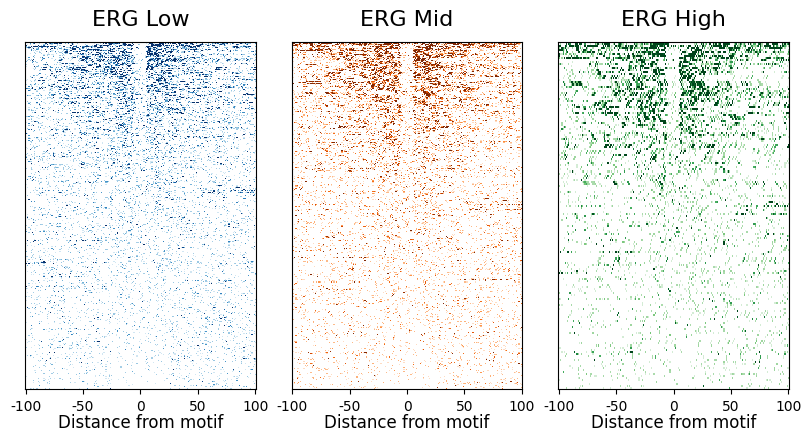

In [6]:
# Plot three positional heatmaps using FIMO score cutoffs
def plot_three_pos_heatmaps_fimo_cutoffs(
    binding_df: pd.DataFrame,
    fp_df: pd.DataFrame,
    *,
    fimo_col: str = "fimo_score",
    vmax: Optional[float] = None,
    width: int = 100,
    figsize: tuple[float, float] = (18, 6),
    interpolation: str = "nearest",
    show_colorbar: bool = True,
    titles: tuple[str, str, str] = ("All", "Top 2/3 unique FIMO", "Top 1/3 unique FIMO"),
    dropna: bool = False,
) -> plt.Figure:

    common_idx = binding_df.index.intersection(fp_df.index)
    if common_idx.size == 0:
        raise ValueError("binding_df and fp_df have no overlapping index values.")

    b = binding_df.loc[common_idx]
    fp = fp_df.loc[common_idx]

    thresholds, _ = fimo_threshold_subsets(b, fimo_col=fimo_col, n_groups=3)
    t_mid = thresholds[1] if len(thresholds) > 1 else thresholds[0]
    t_hi = thresholds[2] if len(thresholds) > 2 else thresholds[-1]

    s_num = pd.to_numeric(b[fimo_col], errors="coerce")
    idx_all = b.index
    idx_mid = b.index[(s_num >= t_mid).fillna(False)]
    idx_hi = b.index[(s_num >= t_hi).fillna(False)]

    fp_all = fp.loc[idx_all]
    fp_mid = fp.loc[idx_mid]
    fp_hi = fp.loc[idx_hi]

    df1, cols1 = _sorted_and_window(fp_all, width)
    df2, cols2 = _sorted_and_window(fp_mid, width)
    df3, cols3 = _sorted_and_window(fp_hi, width)

    if dropna:
        df1 = df1.dropna(subset=cols1)
        df2 = df2.dropna(subset=cols2)
        df3 = df3.dropna(subset=cols3)

    if len(df1) == 0 and len(df2) == 0 and len(df3) == 0:
        raise ValueError("No rows available to plot after filtering.")

    data1 = df1[cols1].to_numpy()
    data2 = df2[cols2].to_numpy()
    data3 = df3[cols3].to_numpy()

    mats = [m for m in (data1, data2, data3) if m.size > 0]
    if not mats:
        raise ValueError("All panels ended up empty after filtering/windowing.")

    vmin_calc = float(np.nanmin([np.nanmin(m) for m in mats]))
    vmax_calc = float(np.nanmax([np.nanmax(m) for m in mats])) if vmax is None else float(vmax)

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    cmap1 = whiten_cmap("Blues", white_frac=0.5)
    cmap2 = whiten_cmap("Oranges", white_frac=0.5)
    cmap3 = whiten_cmap("Greens", white_frac=0.5)

    ims = []
    ims.append(
        axes[0].imshow(
            data1,
            aspect="auto",
            interpolation=interpolation,
            vmin=vmin_calc,
            vmax=vmax_calc,
            cmap=cmap1,
        )
    )
    ims.append(
        axes[1].imshow(
            data2,
            aspect="auto",
            interpolation=interpolation,
            vmin=vmin_calc,
            vmax=vmax_calc,
            cmap=cmap2,
        )
    )
    ims.append(
        axes[2].imshow(
            data3,
            aspect="auto",
            interpolation=interpolation,
            vmin=vmin_calc,
            vmax=vmax_calc,
            cmap=cmap3,
        )
    )

    def set_ticks(ax, cols):
        ncols = len(cols)
        tick_positions = np.linspace(0, ncols - 1, num=min(ncols, 5), dtype=int)
        tick_labels = [int(cols[i].split("_", 1)[1]) for i in tick_positions]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        ax.set_xlabel("Distance from motif", fontsize=12, labelpad=0)

    set_ticks(axes[0], cols1)
    set_ticks(axes[1], cols2)
    set_ticks(axes[2], cols3)

    for ax in axes:
        ax.set_ylabel("")
        ax.tick_params(axis="y", left=False, labelleft=False)

    for ax, title in zip(axes, titles):
        ax.set_title(title, fontsize=16, pad=12)

    if show_colorbar:
        cbar = fig.colorbar(ims[-1], ax=axes.ravel().tolist(), fraction=0.03, pad=0.04)
        cbar.ax.set_ylabel("Value", rotation=270, labelpad=12)

    return fig


fig = plot_three_pos_heatmaps_fimo_cutoffs(
    erg_binding_df,
    erg_fp_df,
    vmax=25,
    width=100,
    figsize=(8, 4.3),
    titles=("ERG Low", "ERG Mid", "ERG High"),
    dropna=False,
    show_colorbar=False
)